In [67]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

In [68]:
vocab_size = 10000      # Kitne words use karne hain
max_length = 200        # Review kitna lamba ho sakta hai
embedding_dim = 128     # Word embedding ka size
lstm_units = 64         # LSTM layer me kitne neurons
batch_size = 128        # Ek baar me kitne reviews train karna
epochs = 10             # Kitni baar pura data dekhna hai

In [69]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"  Training reviews: {len(X_train)}")
print(f"  Testing reviews: {len(X_test)}")
print(f"  Total reviews: {len(X_train) + len(X_test)}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Training reviews: 25000
  Testing reviews: 25000
  Total reviews: 50000


In [79]:
len(X_train[7])

562

In [75]:
print(f"  Length: {len(X_train[2])} words")

print(f"  Label: {y_train[2]} (0=Negative, 1=Positive)")

print(f"  First 10 words (encoded): {X_train[0][:10]}")

  Length: 141 words
  Label: 0 (0=Negative, 1=Positive)
  First 10 words (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]


In [80]:
negative_count = np.sum(y_train == 0)
positive_count = np.sum(y_train == 1)

print(f"\nTraining data:")
print(f"  Negative reviews: {negative_count} ({negative_count/len(y_train)*100:.1f}%)")
print(f"  Positive reviews: {positive_count} ({positive_count/len(y_train)*100:.1f}%)")


Training data:
  Negative reviews: 12500 (50.0%)
  Positive reviews: 12500 (50.0%)


In [81]:
word_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [82]:
reverse_word_index = {}
for word, index in word_index.items():
    reverse_word_index[index + 3] = word

# Special tokens add karo
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'

print(f"  Total words in dictionary: {len(word_index)}")

  Total words in dictionary: 88584


In [83]:
reverse_word_index

{34704: 'fawn',
 52009: 'tsukino',
 52010: 'nunnery',
 16819: 'sonja',
 63954: 'vani',
 1411: 'woods',
 16118: 'spiders',
 2348: 'hanging',
 2292: 'woody',
 52011: 'trawling',
 52012: "hold's",
 11310: 'comically',
 40833: 'localized',
 30571: 'disobeying',
 52013: "'royale",
 40834: "harpo's",
 52014: 'canet',
 19316: 'aileen',
 52015: 'acurately',
 52016: "diplomat's",
 25245: 'rickman',
 6749: 'arranged',
 52017: 'rumbustious',
 52018: 'familiarness',
 52019: "spider'",
 68807: 'hahahah',
 52020: "wood'",
 40836: 'transvestism',
 34705: "hangin'",
 2341: 'bringing',
 40837: 'seamier',
 34706: 'wooded',
 52021: 'bravora',
 16820: 'grueling',
 1639: 'wooden',
 16821: 'wednesday',
 52022: "'prix",
 34707: 'altagracia',
 52023: 'circuitry',
 11588: 'crotch',
 57769: 'busybody',
 52024: "tart'n'tangy",
 14132: 'burgade',
 52026: 'thrace',
 11041: "tom's",
 52028: 'snuggles',
 29117: 'francesco',
 52030: 'complainers',
 52128: 'templarios',
 40838: '272',
 52031: '273',
 52133: 'zaniacs',

In [85]:
X_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [84]:
# review into words
decoded_review = ""
for num in X_train[0]:
    if num != 0:  # Padding skip
        decoded_review += reverse_word_index.get(num, '?') + " "

print(f"\nDecoded review (first 200 characters):")
print(f"{decoded_review[:200]}...")
print(f"\nLabel: {'Positive' if y_train[0] == 1 else 'Negative'}")


Decoded review (first 200 characters):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and ...

Label: Positive


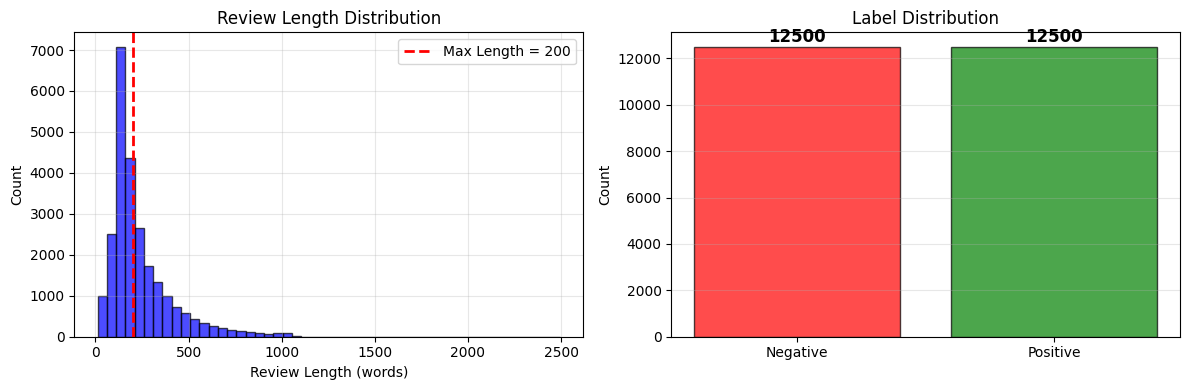

In [86]:
# Review lengths calculate karo
review_lengths = []
for review in X_train:
    review_lengths.append(len(review))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(review_lengths, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(max_length, color='red', linestyle='--', linewidth=2, label=f'Max Length = {max_length}')
plt.xlabel('Review Length (words)')
plt.ylabel('Count')
plt.title('Review Length Distribution')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
labels = ['Negative', 'Positive']
counts = [negative_count, positive_count]
colors = ['red', 'green']
plt.bar(labels, counts, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Count')
plt.title('Label Distribution')
plt.grid(True, alpha=0.3, axis='y')


for i, count in enumerate(counts):
    plt.text(i, count + 200, str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('data_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

In [87]:
# reviews same length
X_train_padded = sequence.pad_sequences(X_train, maxlen=max_length)
X_test_padded = sequence.pad_sequences(X_test, maxlen=max_length)

print(f"\n✓ Padding complete!")
print(f"  X_train shape: {X_train_padded.shape}")
print(f"  X_test shape: {X_test_padded.shape}")

# Example
print(f"\nPehle review padding:")
print(f"  Original length: {len(X_train[0])}")
print(f"  Padded length: {len(X_train_padded[0])}")
print(f"  Padded review start: {X_train_padded[0][:10]}")
print(f"  Padded review end: {X_train_padded[0][-10:]}")


✓ Padding complete!
  X_train shape: (25000, 200)
  X_test shape: (25000, 200)

Pehle review padding:
  Original length: 218
  Padded length: 200
  Padded review start: [  5  25 100  43 838 112  50 670   2   9]
  Padded review end: [4472  113  103   32   15   16 5345   19  178   32]


In [88]:
# Create an empty Sequential model
model = Sequential()

# Layer 1: Embedding layer
# Converts words into dense numerical vectors
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))

# Layer 2: Bidirectional LSTM layer
# Reads the sequence from both forward and backward directions
model.add(Bidirectional(LSTM(lstm_units, return_sequences=True)))

# Layer 3: Dropout layer
# Helps prevent overfitting during training
model.add(Dropout(0.5))

# Layer 4: Second Bidirectional LSTM layer
# Further learns sequence patterns
model.add(Bidirectional(LSTM(lstm_units // 2)))

# Layer 5: Dropout layer
# Reduces overfitting again
model.add(Dropout(0.5))

# Layer 6: Dense (Fully Connected) layer
# Learns high-level features from previous layers
model.add(Dense(64, activation='relu'))

# Layer 7: Dropout layer
# Adds regularization before final prediction
model.add(Dropout(0.3))

# Layer 8: Output layer
# Produces final binary prediction (0 or 1)
model.add(Dense(1, activation='sigmoid'))

print("\n✓ Model architecture ready!")


✓ Model architecture ready!


In [89]:

# Explicitly build the model before calling summary or counting parameters
model.build(input_shape=(None, max_length))


model.summary()

# Parameters count
total_params = model.count_params()
print(f"\n✓ Total parameters: {total_params:,}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,424,257 (5.43 MB)

 Trainable params: 1,424,257 (5.43 MB)

 Non-trainable params: 0 (0.00 B)


✓ Total parameters: 1,424,257


In [90]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [91]:
# Early stopping - if not improvement --stop training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Model checkpoint - best model save
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Learning rate reduction - if learning slow --- LR reduse
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)


In [92]:
callbacks = [early_stop, checkpoint, reduce_lr]

In [93]:
# Model  train
history = model.fit(
    X_train_padded,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6318 - loss: 0.6071
Epoch 1: val_accuracy improved from None to 0.82800, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.7431 - loss: 0.4974 - val_accuracy: 0.8280 - val_loss: 0.3874 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8989 - loss: 0.2689
Epoch 2: val_accuracy improved from 0.82800 to 0.86400, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9008 - loss: 0.2633 - val_accuracy: 0.8640 - val_loss: 0.3309 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9359 - loss: 0.1812
Epoch 3: val_accuracy improved from 0.86400 to 0.87520, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.9324 - loss: 0.1874 - val_accuracy: 0.8752 - val_loss: 0.3713 - learning_rate: 0.0010
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9644 - loss: 0.1092
Epoch 4: val_accuracy did not improve from 0.87520

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9573 - loss: 0.1281 - val_accuracy: 0.8538 - val_loss: 0.3833 - learning_rate: 0.0010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9798 - loss: 0.0723
Epoch 5: val_accuracy did not improve from 0.87520
157/157 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9805 - loss: 0.0674 - val_accuracy: 0.8608 - val_loss: 0.5394 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [ ]:
# Last epoch ke results
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

In [ ]:
print(f"\nFinal Results:")
print(f"  Training Accuracy: {final_train_accuracy:.4f} ({final_train_accuracy*100:.2f}%)")
print(f"  Validation Accuracy: {final_val_accuracy:.4f} ({final_val_accuracy*100:.2f}%)")
print(f"  Training Loss: {final_train_loss:.4f}")
print(f"  Validation Loss: {final_val_loss:.4f}")

# Extract Best epoch
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_accuracy = max(history.history['val_accuracy'])
print(f"\n  Best Validation Accuracy: {best_accuracy:.4f} at epoch {best_epoch}")

In [ ]:
plt.figure(figsize=(14, 5))

epochs_range = range(1, len(history.history['accuracy']) + 1)

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], marker='o', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, history.history['val_accuracy'], marker='s', label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], marker='o', label='Training Loss', linewidth=2, color='red')
plt.plot(epochs_range, history.history['val_loss'], marker='s', label='Validation Loss', linewidth=2, color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
# Test set model evaluate
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=1)

In [ ]:
# Save the final trained model
model.save('final_model.h5')

print("\n✓ Models saved!")
print("  1. best_model.h5 (best checkpoint during training)")
print("  2. final_model.h5 (final trained model)")

# Check the file size of the saved model
import os

if os.path.exists('final_model.h5'):
    size_mb = os.path.getsize('final_model.h5') / (1024 * 1024)
    print(f"\n✓ Model size: {size_mb:.2f} MB")


In [ ]:
# Import model loading function
from tensorflow.keras.models import load_model

# Load the best saved model
loaded_model = load_model('best_model.h5')

print("\n✓ Model loaded successfully!")

# Evaluate the loaded model on test data
loaded_loss, loaded_accuracy = loaded_model.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print(f"\nLoaded model accuracy: {loaded_accuracy:.4f} ({loaded_accuracy*100:.2f}%)")

In [ ]:
# Import model loading function
from tensorflow.keras.models import load_model

# Load the best saved model
loaded_model = load_model('best_model.h5')

print("\n✓ Model loaded successfully!")

# Evaluate the loaded model on test data
loaded_loss, loaded_accuracy = loaded_model.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print(f"\nLoaded model accuracy: {loaded_accuracy:.4f} ({loaded_accuracy*100:.2f}%)")


# ----------------------------------------------------------------------------
#  Make prediction on a custom review
# ----------------------------------------------------------------------------
# Example review for testing
test_review_text = "This movie was absolutely fantastic! Great acting and amazing story."

print(f"\nTest Review: {test_review_text}")

# Process the review text

# Step 1: Convert text to lowercase and split into words
words = test_review_text.lower().split()

# Step 2: Convert words into numerical indices
encoded_review = []

for word in words:
    if word in word_index:
        # Add 3 because first indices are reserved for special tokens
        index = word_index[word] + 3

        # Only keep words within vocabulary size
        if index < vocab_size:
            encoded_review.append(index)

    else:
        # Use index 2 for unknown words
        encoded_review.append(2)

# Step 3: Add padding to match input length
padded_review = sequence.pad_sequences(
    [encoded_review],
    maxlen=max_length
)

# Step 4: Predict sentiment
prediction = loaded_model.predict(padded_review, verbose=0)

# Extract prediction value
prediction_value = prediction[0][0]

# Step 5: Determine final sentiment result
if prediction_value >= 0.5:
    sentiment = "POSITIVE 😊"
    confidence = prediction_value * 100

else:
    sentiment = "NEGATIVE 😞"
    confidence = (1 - prediction_value) * 100

# Display prediction result
print(f"\n{'='*70}")
print(f"PREDICTION RESULT")
print(f"{'='*70}")
print(f"  Sentiment: {sentiment}")
print(f"  Confidence: {confidence:.2f}%")
print(f"  Raw Score: {prediction_value:.4f}")
print(f"{'='*70}")

In [ ]:
# List of multiple test reviews
test_reviews = [
    "This movie was terrible and boring. Complete waste of time.",
    "Amazing film! Best movie I have seen this year. Highly recommended!",
    "It was okay. Not great but not bad either.",
    "Absolutely loved it! Perfect in every way.",
    "Worst movie ever. Don't waste your money."
]

print("\nTesting multiple reviews:\n")

# Predict sentiment for each review
for idx, review_text in enumerate(test_reviews, 1):

    # Step 1: Convert review to lowercase and split into words
    words = review_text.lower().split()

    # Step 2: Encode words into numerical indices
    encoded = []

    for word in words:

        if word in word_index:

            # Add 3 because first indices are reserved for special tokens
            index = word_index[word] + 3

            # Keep only words within vocabulary size
            if index < vocab_size:
                encoded.append(index)

        else:
            # Use index 2 for unknown words
            encoded.append(2)

    # Step 3: Add padding to make equal input length
    padded = sequence.pad_sequences(
        [encoded],
        maxlen=max_length
    )

    # Step 4: Predict sentiment score
    pred = loaded_model.predict(
        padded,
        verbose=0
    )[0][0]

    # Step 5: Determine sentiment label
    if pred >= 0.5:
        sent = "POSITIVE 😊"
        conf = pred * 100

    else:
        sent = "NEGATIVE 😞"
        conf = (1 - pred) * 100

    # Step 6: Display prediction result
    print(f"Review {idx}:")
    print(f"  Text: {review_text}")
    print(f"  Prediction: {sent}")
    print(f"  Confidence: {conf:.2f}%")
    print()